## Boolean analysis

Here we are trying to apply Boolean Fourier Analysis to the sign structure. The main reference is:

- Ryan O'Donnel. [Analysis of Boolean Functions](http://www.cs.cmu.edu/~odonnell/papers/Analysis-of-Boolean-Functions-by-Ryan-ODonnell.pdf).

Caveat: our space is not a space of boolean functions defined on $\{0,1\}^n$, as we are working in the sector of zero magnetization (equal number of spins up and down). So, the set of parity functions that is used as a basis in BFA is *not* an orthonormal basis of the space of boolean functions defined in the sector of zero magnetization.

Possible workarounds:

- It is possible to consider the full eigenstate $\{0, 1\}^n \to \mathbb R$, not only the sign structure. Products are still form the orthonormal basis in this space.
- It is possible to consider the sign structure with zeroes: $\{0, 1\}^n \to \{-1, 0, 1\}$.

In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

In [2]:
from pathlib import Path

FOURIER_BASIS_DIR = Path("fourier-bases")
FOURIER_BASIS_DIR.mkdir(exist_ok=True)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
from tqdm.auto import tqdm
from pathlib import Path
from typing import Literal

from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
    SpinSystem,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
)

from scipy.stats import entropy

%matplotlib inline

/home/ischurov/.conda/envs/latsym/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def parity_of_1s(x: np.ndarray, n: int, show_progress=False):
    """
    Calculates the parities of number of 1's for all elements of x

    Params
    ------
    x : np.ndarray
        should have dtype == 'uint64'

    n : int
        number of bits (all elements of x should be less than 2 ** n)

    show_progress : bool
                    whether to show progress bar

    Returns
    -------
    parity : np.ndarray
             dtype == 'uint8'
    """

    parity = np.zeros_like(x, dtype="uint8")
    x = x.copy()
    for i in [lambda _: _, tqdm][show_progress](range(n)):
        parity ^= x & 1
        x >>= 1
    return parity


assert (
    np.isclose(
        parity_of_1s(np.array([[1, 2, 3], [4, 5, 6]], dtype="uint64"), 3),
        np.array([[1, 1, 0], [1, 0, 0]], dtype="uint64"),
    )
).all()

In [5]:
class BooleanFourierAnalyser:
    def __init__(self, system: SpinSystem, fourier_basis_cache=None):
        self.system = system

        number_spins = self.system.number_spins
        canonical_basis = self.system.canonical_basis

        fourier_basis_path = FOURIER_BASIS_DIR / Path(
            f"fourier_basis-{number_spins}-"
            f"{canonical_basis.hamming_weight}.feather"
        )

        self.fourier_basis = None

        if fourier_basis_cache is not None:
            states = tuple(self.system.canonical_basis.states)
            if (
                cached_basis := fourier_basis_cache.get(
                    (states, self.system.number_spins)
                )
            ) is not None:
                print("Found cached fourier basis, will use it")
                self.fourier_basis = cached_basis

        if self.fourier_basis is None:
            if fourier_basis_path.exists():
                print(f"Fourier basis found at {fourier_basis_path}")
                fourier_basis_df = pd.read_feather(
                    fourier_basis_path
                ).set_index("index")
                if (fourier_basis_df.index != canonical_basis.states).any():
                    raise ValueError(
                        f"basis states in file {fourier_basis_path} do not coincide with "
                        f"self.system.canonical_basis"
                    )
                self.fourier_basis = fourier_basis_df.values.astype("int8")

        if self.fourier_basis is None:
            print(
                "Fourier basis not found, we have to calculate it. "
                "This can take some time, you can get a coffee."
            )
            self.fourier_basis = self.make_fourier_basis()

        if not fourier_basis_path.exists():
            print(f"Saving basis to file {fourier_basis_path}")
            pd.DataFrame(
                self.fourier_basis,
                index=self.system.canonical_basis.states.astype("uint64"),
                columns=[str(i) for i in range(2**self.system.number_spins)],
            ).reset_index().to_feather(fourier_basis_path)

        if fourier_basis_cache is not None:
            fourier_basis_cache[
                (states, self.system.number_spins)
            ] = self.fourier_basis

        print("Finding system ground state")
        self.system.get_ground_state()

    def make_fourier_basis(self):
        masks = (
            np.arange(2**self.system.number_spins)
            .reshape(1, -1)
            .astype("uint64")
        )
        masked = self.system.canonical_basis.states.reshape(-1, 1) & masks
        parities = parity_of_1s(
            masked, self.system.number_spins, show_progress=True
        )
        return parities.astype("int8") * 2 - 1

    def fourier_decomposition(self, signal):
        return self.fourier_basis.T @ signal / self.fourier_basis.shape[0]

    def fourier_spectre_df(self, signal: Literal["sign", "value"]):
        signal_ = self.system.get_df_ground_state(canonical_basis=True)[
            "ground_state_coeff"
        ]
        if signal == "sign":
            signal_ = np.sign(signal_)

        return (
            pd.DataFrame(
                dict(
                    subset=list(
                        make_unpacked_configurations(
                            np.arange(
                                2**self.system.number_spins, dtype="uint64"
                            ),
                            number_spins=self.system.number_spins,
                        )
                    ),
                    coeff=self.fourier_decomposition(signal_),
                )
            )
            .assign(abs_coeff=lambda x: np.abs(x["coeff"]))
            .sort_values("abs_coeff", ascending=False)
        )

In [6]:
fourier_basis_cache = {}

In [7]:
analyzer = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        SquareLattice(width=4, height=4),
        J1=1,
        J2=0,
        use_symmetries=True,
        spin_inversion=1,
    ),
    fourier_basis_cache=fourier_basis_cache,
)

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Fourier basis not found, we have to calculate it. This can take some time, you can get a coffee.


100%|██████████| 16/16 [01:57<00:00,  7.31s/it]


Saving basis to file fourier-bases/fourier_basis-16-8.feather
Finding system ground state
Using cached version of eigenvalues / eigenstates
Ground state energy is -44.9139328337


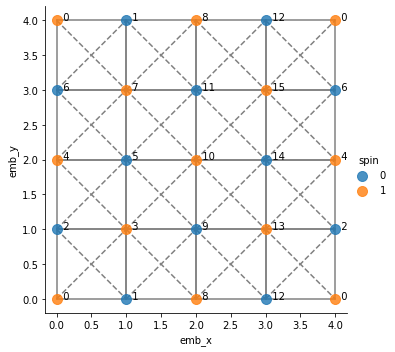

In [8]:
spectre_df_sign = analyzer.fourier_spectre_df(signal="sign")
spectre_df_value = analyzer.fourier_spectre_df(signal="value")

analyzer.system.lat.plot(spins=spectre_df_sign["subset"].iloc[0])

Okay, that's the Marshall's sign rule. Seems to be working.

<AxesSubplot: >

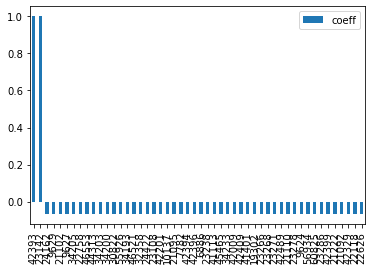

In [9]:
spectre_df_sign.iloc[:50].plot.bar(y="coeff")

<AxesSubplot: >

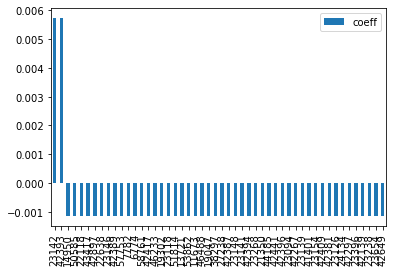

In [10]:
spectre_df_value.iloc[:50].plot.bar(y="coeff")

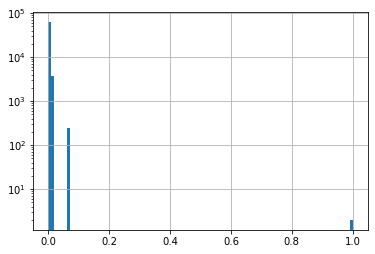

In [11]:
spectre_df_sign["abs_coeff"].hist(bins=100)
plt.yscale("log")

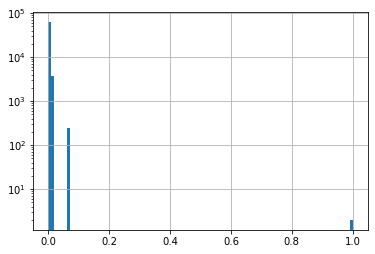

In [12]:
analyzer.fourier_spectre_df(signal="sign")["abs_coeff"].hist(bins=100)
plt.yscale("log")

In [13]:
def abs_norm(x):
    x = np.abs(x)
    return x / np.sum(x)

In [14]:
entropy(abs_norm(spectre_df_sign["abs_coeff"]))

10.224568940646584

In [15]:
entropy(abs_norm(spectre_df_value["abs_coeff"]))

9.120175397182347

In [16]:
entropy(abs_norm(analyzer.system.get_df_ground_state()["amplitude"] ** 2))

3.2449912831304033

In [17]:
entropy(np.array([0.25, 0.25, 0.25, 0.25]))

1.3862943611198906

Entropy seems to be wrong measure of "spreadness" of the function over the basis.

<AxesSubplot: >

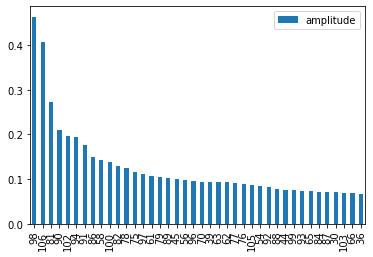

In [18]:
analyzer.system.get_df_ground_state().sort_values(
    "amplitude", ascending=False
).iloc[:40].plot.bar(y="amplitude")

<AxesSubplot: >

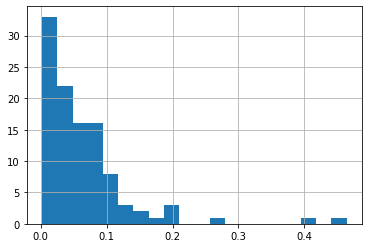

In [19]:
analyzer.system.get_df_ground_state()["amplitude"].hist(bins=20)